# Quantum Teleportation.

Quantum teleportation is a process by which the state of a quantum system can be transmitted from one location to another, without the physical transfer of the system itself. This is achieved through the use of quantum entanglement and classical communication.

**Here is how it works simply:**
- 1. **Alice** has a secret quantum message (Qubit 0).
- 2. Alice and **Bob** share an entangled pair of qubits (Qubit 1 and Qubit 2). This is "telephoe line."
- 3. Alice entangles her secret message with her half of the telephone line, measures them, and tells Bob the result.
- 4. Bob uses that information to magically transform his quibt into Alice's original secret message!

In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

### We need 3 qubits for teleportation.
- Qubit 0: The qubit that Alice wants to teleport (the secret message).
- Qubit 1: Alice's half of the entangled pair.
- Qubit 2: Bob's half of the entangled pair.

`We need 1 classical bit to measure Bob's final result.`

In [3]:
qc = QuantumCircuit(3, 1)

### --- STEP 1: Create Alice's Secret Message ---
- Let's flip Qubit 0 to |1⟩ using an X gate (like a classical NOT gate).
- This is the message we want to teleport to Bob.

In [4]:
qc.x(0)
qc.barrier() # Draws a visual line to separate steps

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>), clbits=())

### --- STEP 2: Create the Entangled "Telephone Line" ---
- Create a Bell State between Qubit 1 (Alice) and Qubit 2 (Bob)

In [5]:
qc.h(1)
qc.cx(1, 2)
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>), clbits=())

### --- STEP 3: Alics sends her message into the telephone line ---

In [6]:
qc.cx(0, 1)
qc.h(0)
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>), clbits=())

### --- STEP 4: Bob receives the message and decodes it ---
- Bob applies an X gate if Qubit 1 is a 1
- Bob applies a Z gate if Qubit 0 is a 1

In [7]:
qc.cx(1, 2)
qc.cz(0, 2)

### -- STEP 5: Measue Bob's Qubit ---
- If teleportation worked, Bob's qubit (Qubit 2) should now be a 1!

In [8]:
qc.measure(2, 0)

### Draw the circuit

Quantum Teleportation Circuit:


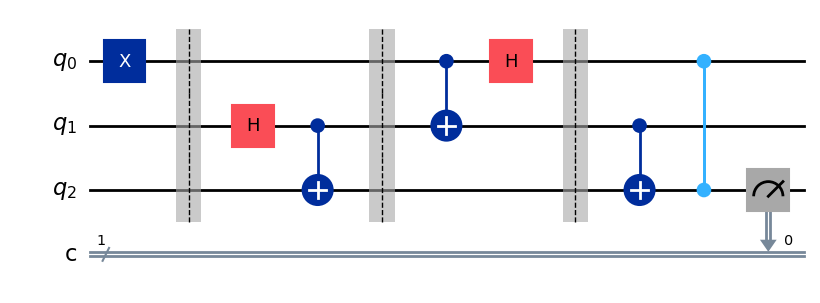

In [9]:
print("Quantum Teleportation Circuit:")
display(qc.draw("mpl"))

### Run the simulation

In [10]:
simulator = AerSimulator()
job = simulator.run(qc, shots=1000)
result = job.result()

### Show the results

Results: {'1': 1000}


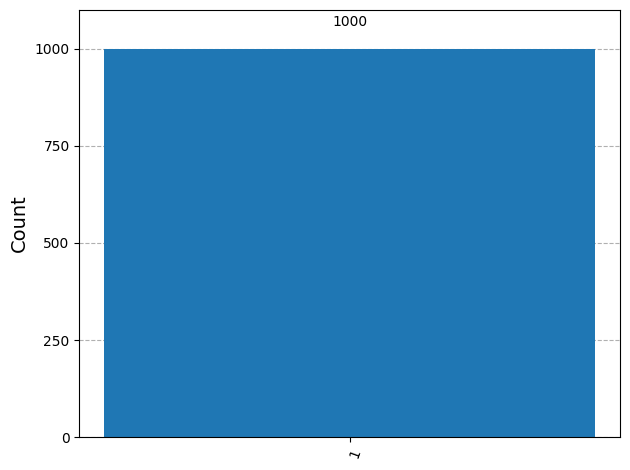

In [11]:
counts = result.get_counts(qc)
print(f"Results: {counts}")
display(plot_histogram(counts))